# From a Stateless LLM to a Grounded ADK Agent

This notebook follows one small shopping story from a plain LLM call to an agent with a session and a tool. All inference uses **OpenRouter**.

> **Tracing notice:** automatic tracing sends model and agent activity to the shared Langfuse project. Traces are **private by default**. Use only the synthetic demo data supplied here; never enter secrets, personal data, or real customer information.

## Goal

By the end, you can explain why:

1. independent LLM calls do not remember each other;
2. resending messages can make a call appear to remember;
3. an ADK session carries conversation history across turns; and
4. a tool supplies facts that are not present in the conversation.

## Setup

### 1. Install the libraries

Run this once. If Jupyter asks for a kernel restart, restart it and continue from the environment cell.

In [ ]:
%pip install -q "google-adk[extensions]>=1.26.0" "langfuse>=3.0" \
    openinference-instrumentation-google-adk openinference-instrumentation-openai \
    openai python-dotenv nbformat

### 2. Create your local `.env`

From the repository root, copy the safe template once:

```bash
cp .env.example .env
```

Open `.env` and fill in your OpenRouter and Langfuse keys. The repository ignores `.env`; never commit it or paste credentials into notebook cells.

### 3. Load the environment and enable tracing

This cell reads `.env`, validates the required values without printing them, and initializes instrumentation once for the whole notebook.

In [ ]:
import os

from dotenv import load_dotenv
from langfuse import get_client
from openinference.instrumentation.google_adk import GoogleADKInstrumentor
from openinference.instrumentation.openai import OpenAIInstrumentor

load_dotenv()

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "").strip()
LANGFUSE_PUBLIC_KEY = os.getenv("LANGFUSE_PUBLIC_KEY", "").strip()
LANGFUSE_SECRET_KEY = os.getenv("LANGFUSE_SECRET_KEY", "").strip()
LANGFUSE_BASE_URL = os.getenv(
    "LANGFUSE_BASE_URL", "https://us.cloud.langfuse.com"
).strip()
OPENROUTER_MODEL = os.getenv(
    "OPENROUTER_MODEL", "openai/gpt-4.1-mini"
).strip()

required_values = {
    "OPENROUTER_API_KEY": OPENROUTER_API_KEY,
    "LANGFUSE_PUBLIC_KEY": LANGFUSE_PUBLIC_KEY,
    "LANGFUSE_SECRET_KEY": LANGFUSE_SECRET_KEY,
}
missing = [name for name, value in required_values.items() if not value]
if missing:
    raise ValueError(
        "Copy .env.example to .env, fill the missing values, and rerun this cell: "
        + ", ".join(missing)
    )

os.environ["OPENROUTER_API_KEY"] = OPENROUTER_API_KEY
os.environ["LANGFUSE_PUBLIC_KEY"] = LANGFUSE_PUBLIC_KEY
os.environ["LANGFUSE_SECRET_KEY"] = LANGFUSE_SECRET_KEY
os.environ["LANGFUSE_BASE_URL"] = LANGFUSE_BASE_URL

langfuse = get_client()
if not langfuse.auth_check():
    raise RuntimeError("Langfuse authentication failed. Check the keys and region URL.")

if not globals().get("_INSTRUMENTATION_ENABLED", False):
    GoogleADKInstrumentor().instrument()
    OpenAIInstrumentor().instrument()
    _INSTRUMENTATION_ENABLED = True

print(f"Environment loaded. Automatic tracing enabled for model={OPENROUTER_MODEL!r}")

## Steps

### Step 1 — Tell a plain LLM your preference

This is one request and one response. There is no ADK agent, session, or tool. The helper below only keeps the repeated OpenRouter call short; it does not store conversation history.

In [ ]:
from openai import OpenAI

openrouter = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
)

SYSTEM_INSTRUCTION = (
    "Answer concisely using only facts in the messages you receive. "
    "If an earlier preference is not included, say you do not know it. "
    "Never guess a product price."
)


def ask_llm(messages: list[dict], trace_name: str) -> str:
    with langfuse.start_as_current_observation(
        name=trace_name,
        as_type="span",
    ):
        response = openrouter.chat.completions.create(
            model=OPENROUTER_MODEL,
            messages=[
                {"role": "system", "content": SYSTEM_INSTRUCTION},
                *messages,
            ],
        )
        return response.choices[0].message.content

In [ ]:
preference_messages = [
    {"role": "user", "content": "I like almond milk."}
]
preference_answer = ask_llm(
    preference_messages,
    "01 — State preference",
)

print(preference_answer)

### Step 2 — Ask again in an independent call

This request contains only the new question. The model receives no hidden state from Step 1, so it cannot know the preference or a catalog price.

In [ ]:
independent_messages = [
    {
        "role": "user",
        "content": "What is my favorite milk, and how much does it cost?",
    }
]
independent_answer = ask_llm(
    independent_messages,
    "02 — Stateless question",
)

print(independent_answer)

The calls are independent:

```text
call 1: ["I like almond milk."]
call 2: ["What is my favorite milk, and how much does it cost?"]
```

An LLM API is a function over the messages supplied in the current request. It does not automatically recover messages from an earlier call.

### Step 3 — Bridge the calls by resending history

Now the application explicitly rebuilds the conversation. The model can identify almond milk because that preference is in this request. It still cannot verify a price because the messages contain no catalog result.

In [ ]:
bridge_messages = preference_messages + [
    {"role": "assistant", "content": preference_answer},
    {
        "role": "user",
        "content": "What is my favorite milk, and how much does it cost?",
    },
]
bridge_answer = ask_llm(
    bridge_messages,
    "03 — Resend history",
)

print(bridge_answer)

### Step 4 — Add a generic item-search tool

The catalog is synthetic and includes several kinds of items. `search_items` is a normal application capability, not a milk-specific trick.

ADK turns the typed function and docstring into a tool schema. The model chooses the arguments; Python performs the deterministic search.

In [ ]:
CATALOG = [
    {
        "item_id": "milk-001",
        "name": "Almond Milk",
        "description": "Unsweetened dairy-free almond drink",
        "price": 3.49,
    },
    {
        "item_id": "milk-002",
        "name": "Oat Milk",
        "description": "Creamy dairy-free oat drink",
        "price": 4.19,
    },
    {
        "item_id": "food-001",
        "name": "Crunchy Oat Cereal",
        "description": "Whole-grain breakfast cereal",
        "price": 5.29,
    },
    {
        "item_id": "produce-001",
        "name": "Honeycrisp Apples",
        "description": "Bag of crisp red apples",
        "price": 6.49,
    },
]


def search_items(query: str) -> list[dict]:
    """Search the synthetic product catalog by item name or description.

    Args:
        query: Words describing the catalog item to find.
    """
    words = {
        word.lower().strip(".,?!")
        for word in query.split()
        if word.strip(".,?!")
    }
    results = []
    for item in CATALOG:
        searchable = f'{item["name"]} {item["description"]}'.lower()
        if words and all(word in searchable for word in words):
            results.append(item)
    return results

In [ ]:
search_items("almond milk")

### Step 5 — Let an ADK agent use a session and the tool

An ADK `Agent` combines the model, instructions, and tools. `InMemoryRunner` manages a conversation session and the agent loop.

We will send the same two user messages as before, but this time both turns use one session ID. The preference comes from the session history; the price comes from `search_items`.

In [ ]:
from google.adk.agents import Agent
from google.adk.models.lite_llm import LiteLlm
from google.adk.runners import InMemoryRunner

adk_model = LiteLlm(model=f"openrouter/{OPENROUTER_MODEL}")

shopping_agent = Agent(
    name="shopping_assistant",
    model=adk_model,
    instruction=(
        "You are a concise shopping assistant. Use this session's conversation "
        "to recall preferences. Acknowledge a preference without using a tool. "
        "You MUST call search_items before stating any catalog price, and base "
        "prices only on returned rows. If no row matches, say so."
    ),
    tools=[search_items],
)
agent_runner = InMemoryRunner(
    agent=shopping_agent,
    app_name="04_agent_with_catalog",
)

In [ ]:
await agent_runner.run_debug(
    "I like almond milk.",
    session_id="shopping-session",
    verbose=True,
)

In [ ]:
await agent_runner.run_debug(
    "What is my favorite milk, and how much does it cost?",
    session_id="shopping-session",
    verbose=True,
)

## Checks

Flush buffered telemetry before opening Langfuse:

In [ ]:
langfuse.flush()
print("Traces flushed to Langfuse.")

Langfuse should now show the notebook's activity automatically:

| Example | What to inspect |
| --- | --- |
| Preference call | The request includes almond milk |
| Independent question | The request contains no earlier preference |
| Bridge call | The application resends the earlier messages |
| First ADK turn | The preference enters `shopping-session` |
| Second ADK turn | Model → `search_items` → model trajectory |

### Share a demonstration trace

In Langfuse, open **Traces**, select the demonstration trace, choose **Share**, and copy the public URL. Anyone with that URL can view the shared trace without logging in. Share only the supplied synthetic demonstrations.

Questions:

1. Which request first contains enough context to identify almond milk?
2. Why can the bridge call identify the preference but not verify a price?
3. In the final agent trace, which information came from the session and which came from the tool?

### Read the traces

#### 1. `02 — Stateless question`

[Open this public Langfuse trace](https://us.cloud.langfuse.com/project/cmrk2qw7q0aycad0c1ejw7h2e/traces/9fd84c8e6b1e7c5a98d4171ad03bc2cb?observation=0402ca75e57c99fb&timestamp=2026-07-14T04%3A17%3A58.002Z)

Read the highlighted regions as:

- **Green:** the system and user messages sent to the model.
- **Red:** the assistant's output. It cannot recover the missing preference.
- **Blue:** prompt, completion, and total token counts.

The red and blue overlay captions in the screenshot repeat “Input Message”; the mapping above is the correct interpretation.

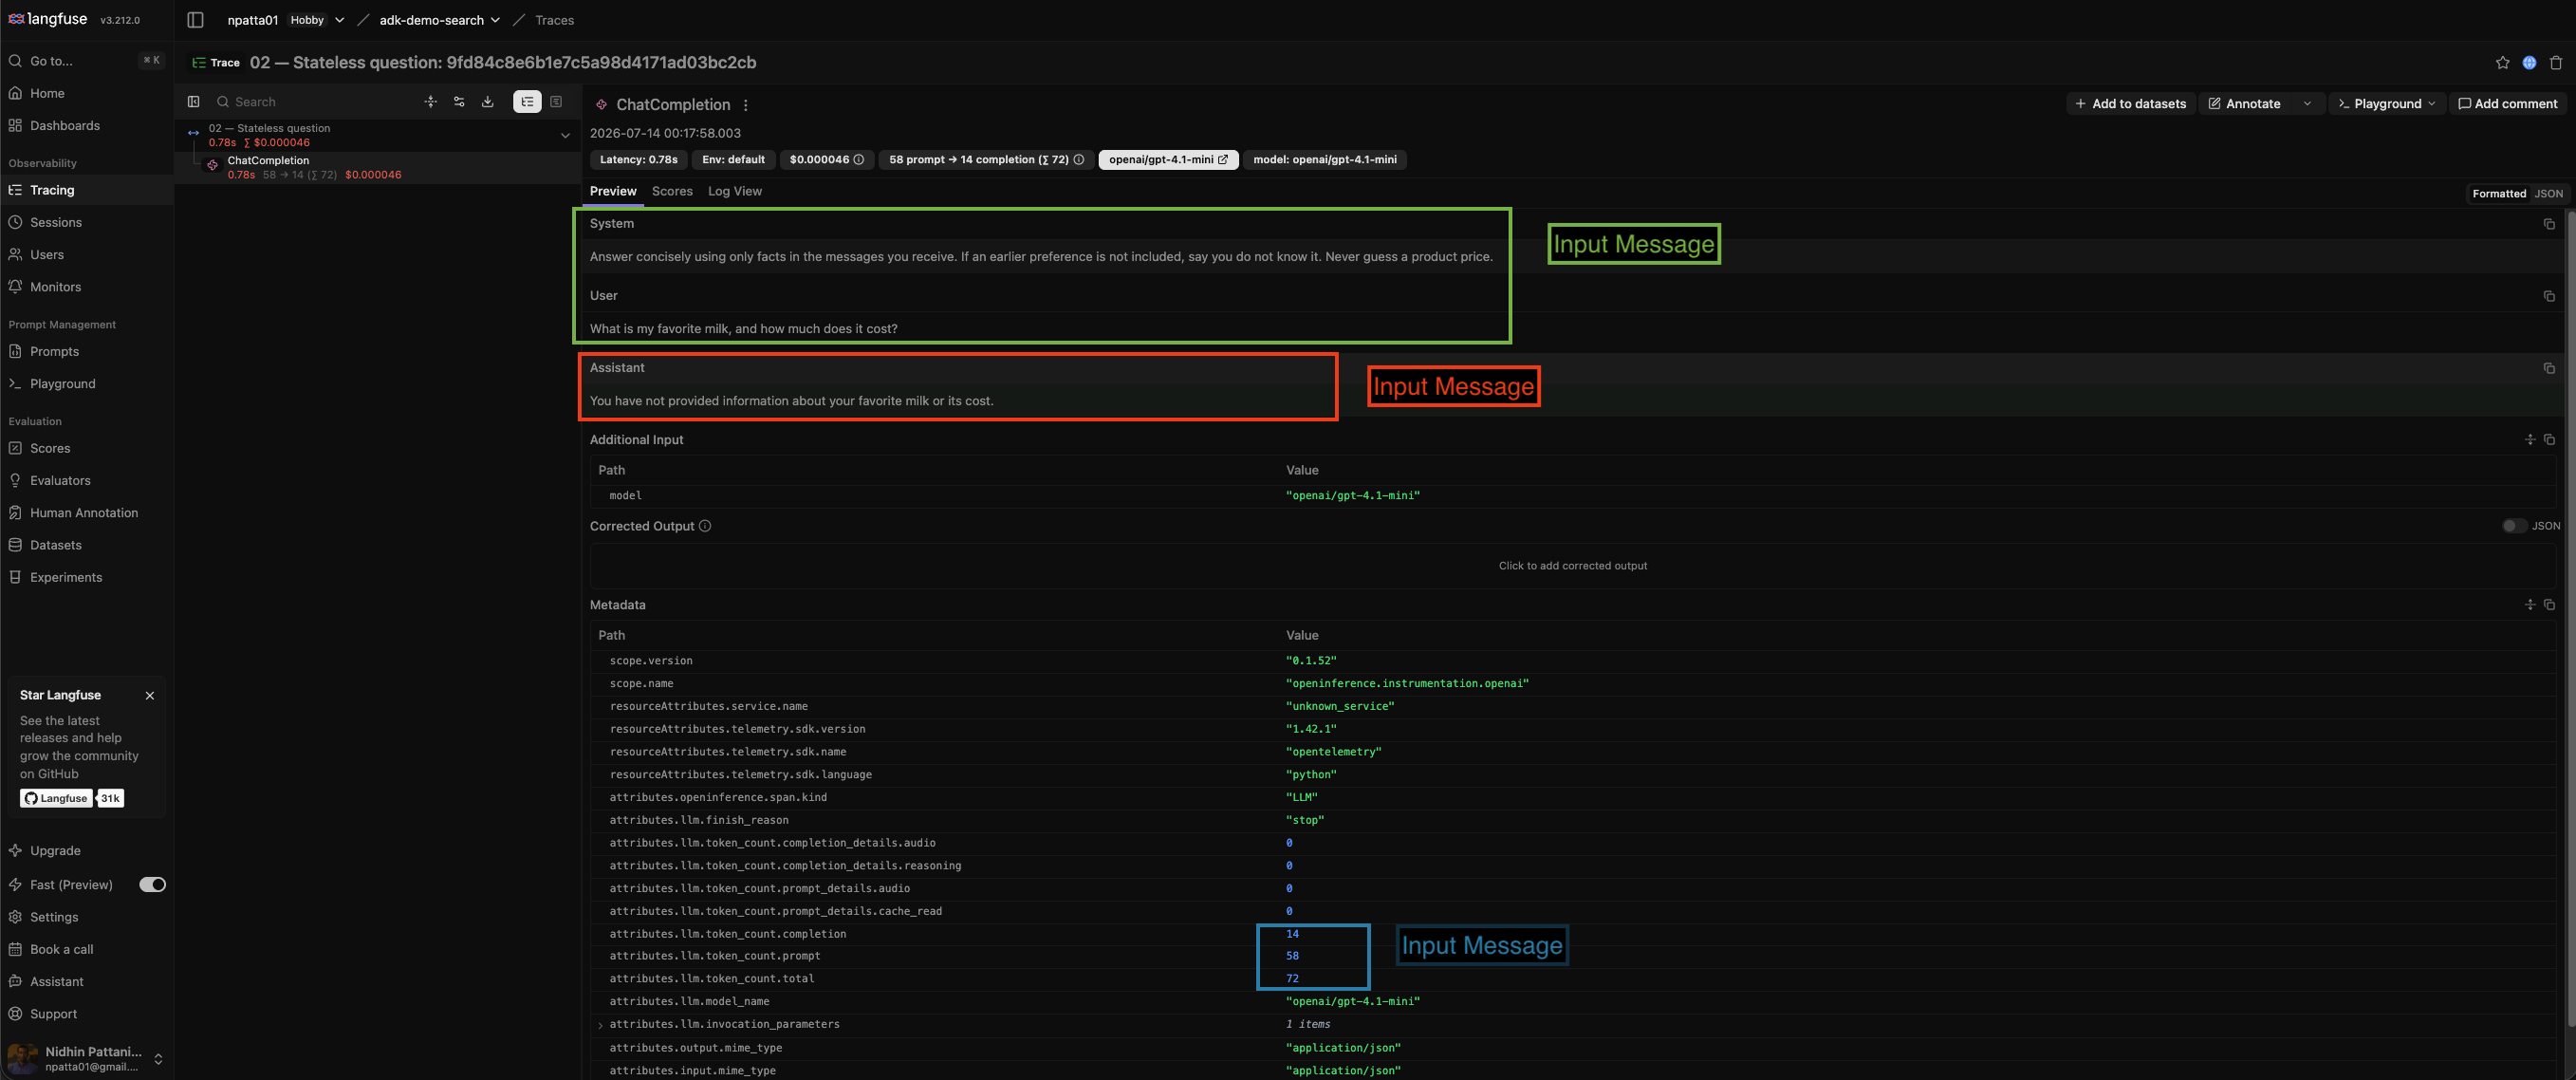

#### 2. Model → tool → model

[Open this public ADK agent trace](https://us.cloud.langfuse.com/project/cmrk2qw7q0aycad0c1ejw7h2e/traces/b2b0b8ecc498dabc78687ca061d9048a?observation=7e1080235add254e&timestamp=2026-07-14T04%3A18%3A03.599Z)

Follow the left-hand trace tree and the highlighted messages:

- The first `call_llm` reads the session history and requests `search_items(query="almond milk")`.
- `search_items` returns the catalog row, including `price: 3.49`.
- The second `call_llm` uses that tool result to produce the grounded answer.

In the screenshot, **blue is the model's function call** and **green is the tool result**. The duplicated green overlay caption should read “Tool result.”

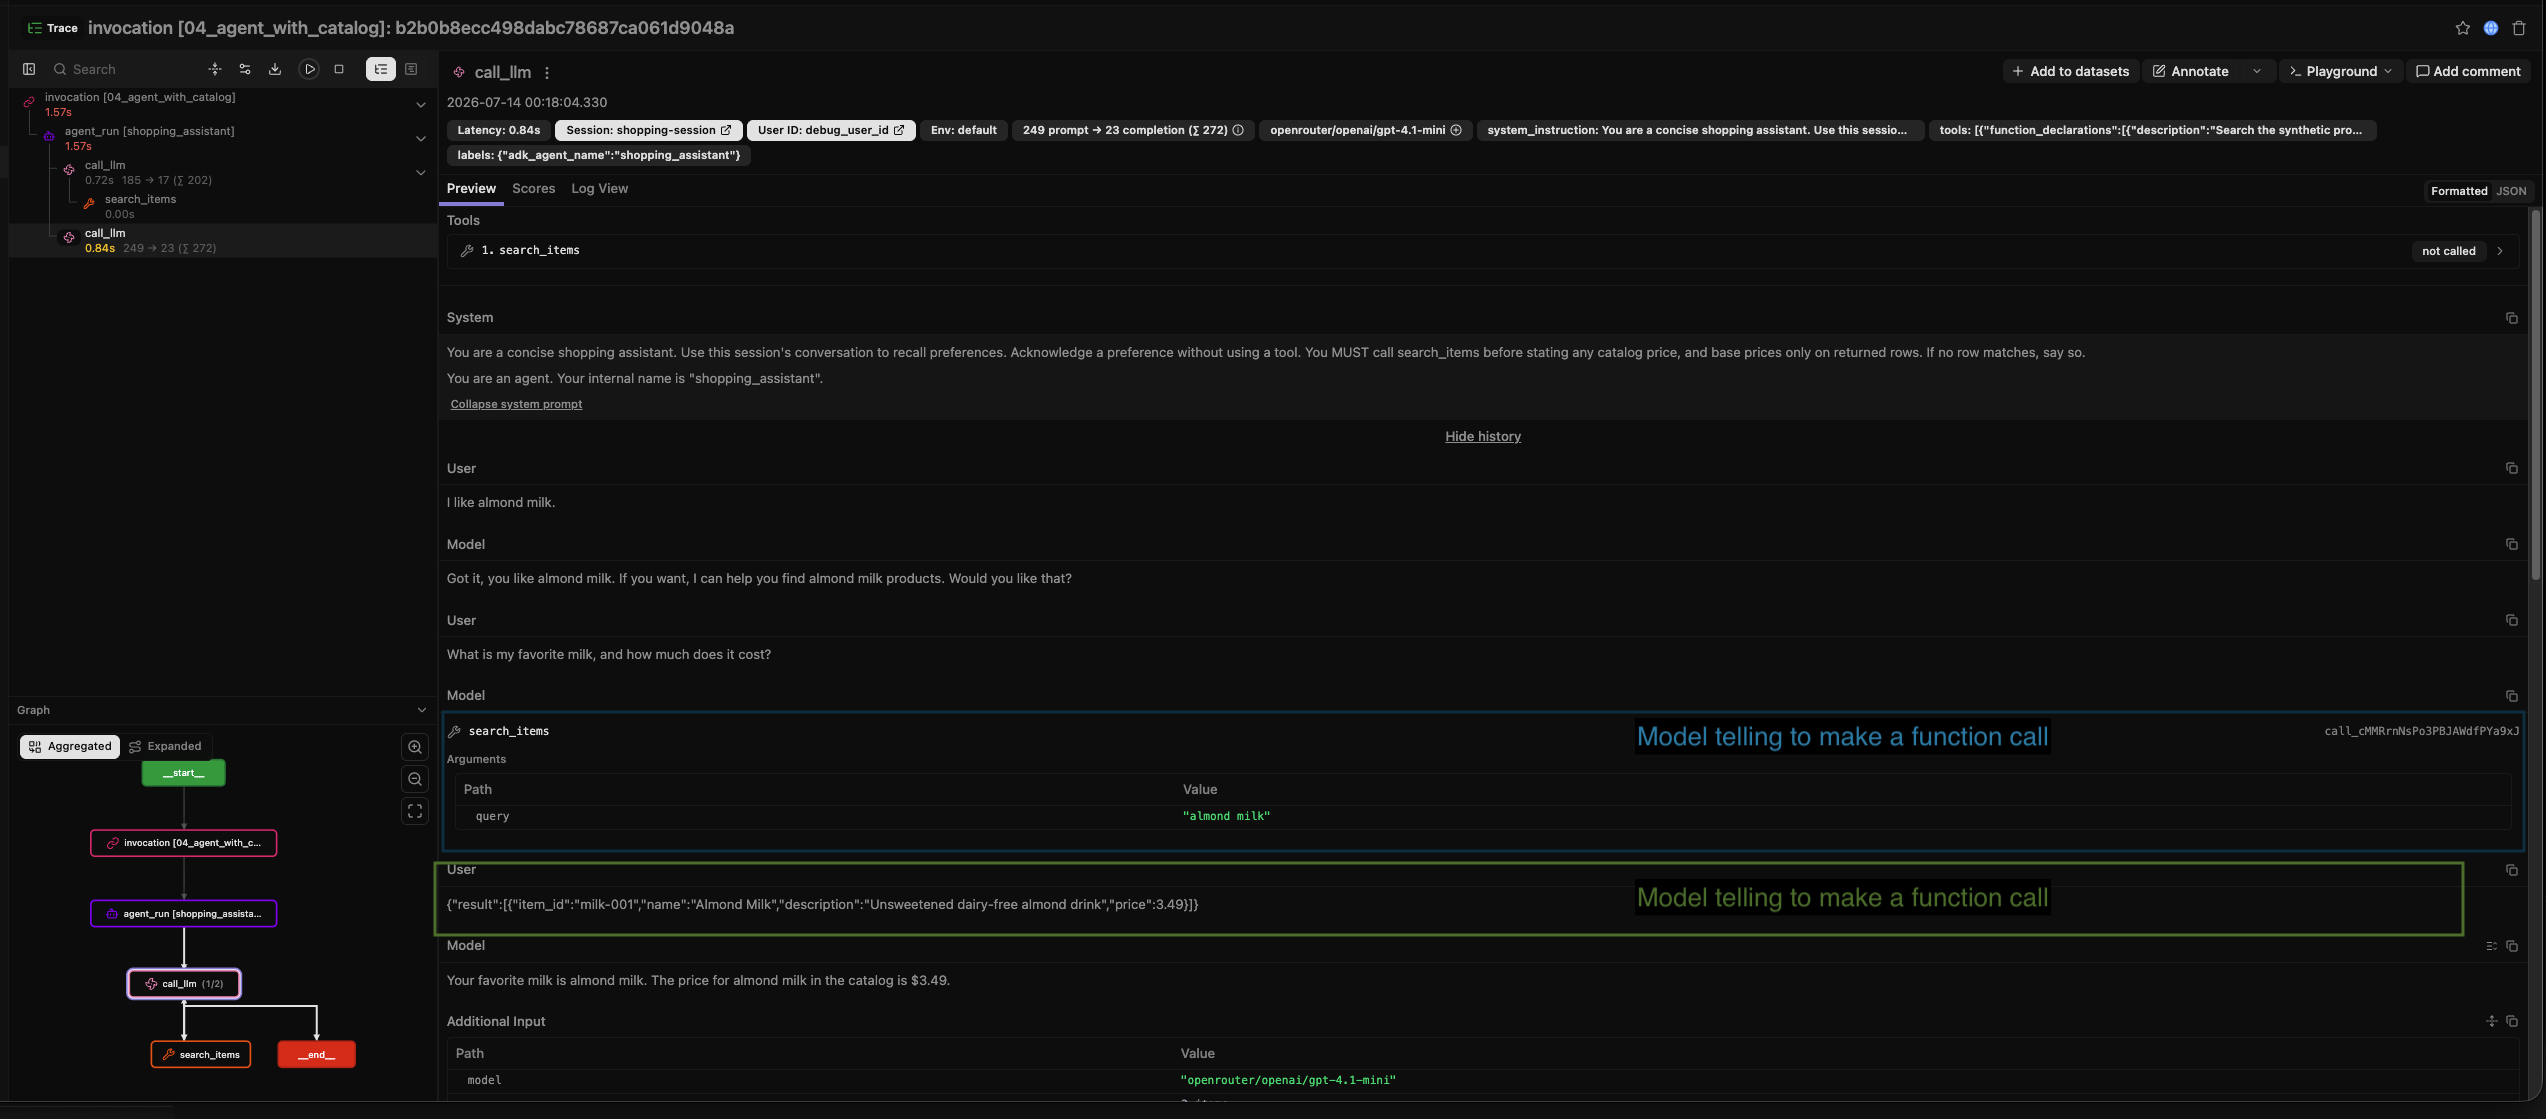

#### 3. Function call and tool definition

[Open the same public ADK agent trace](https://us.cloud.langfuse.com/project/cmrk2qw7q0aycad0c1ejw7h2e/traces/b2b0b8ecc498dabc78687ca061d9048a?observation=7e1080235add254e&timestamp=2026-07-14T04%3A18%3A03.599Z)

This JSON view exposes two different objects:

- **Function call:** the model-generated request containing the tool name and `query` argument.
- **Function definition:** the schema ADK generated from the Python function's name, type hints, and docstring.

The model proposes a call. ADK executes the real Python function.

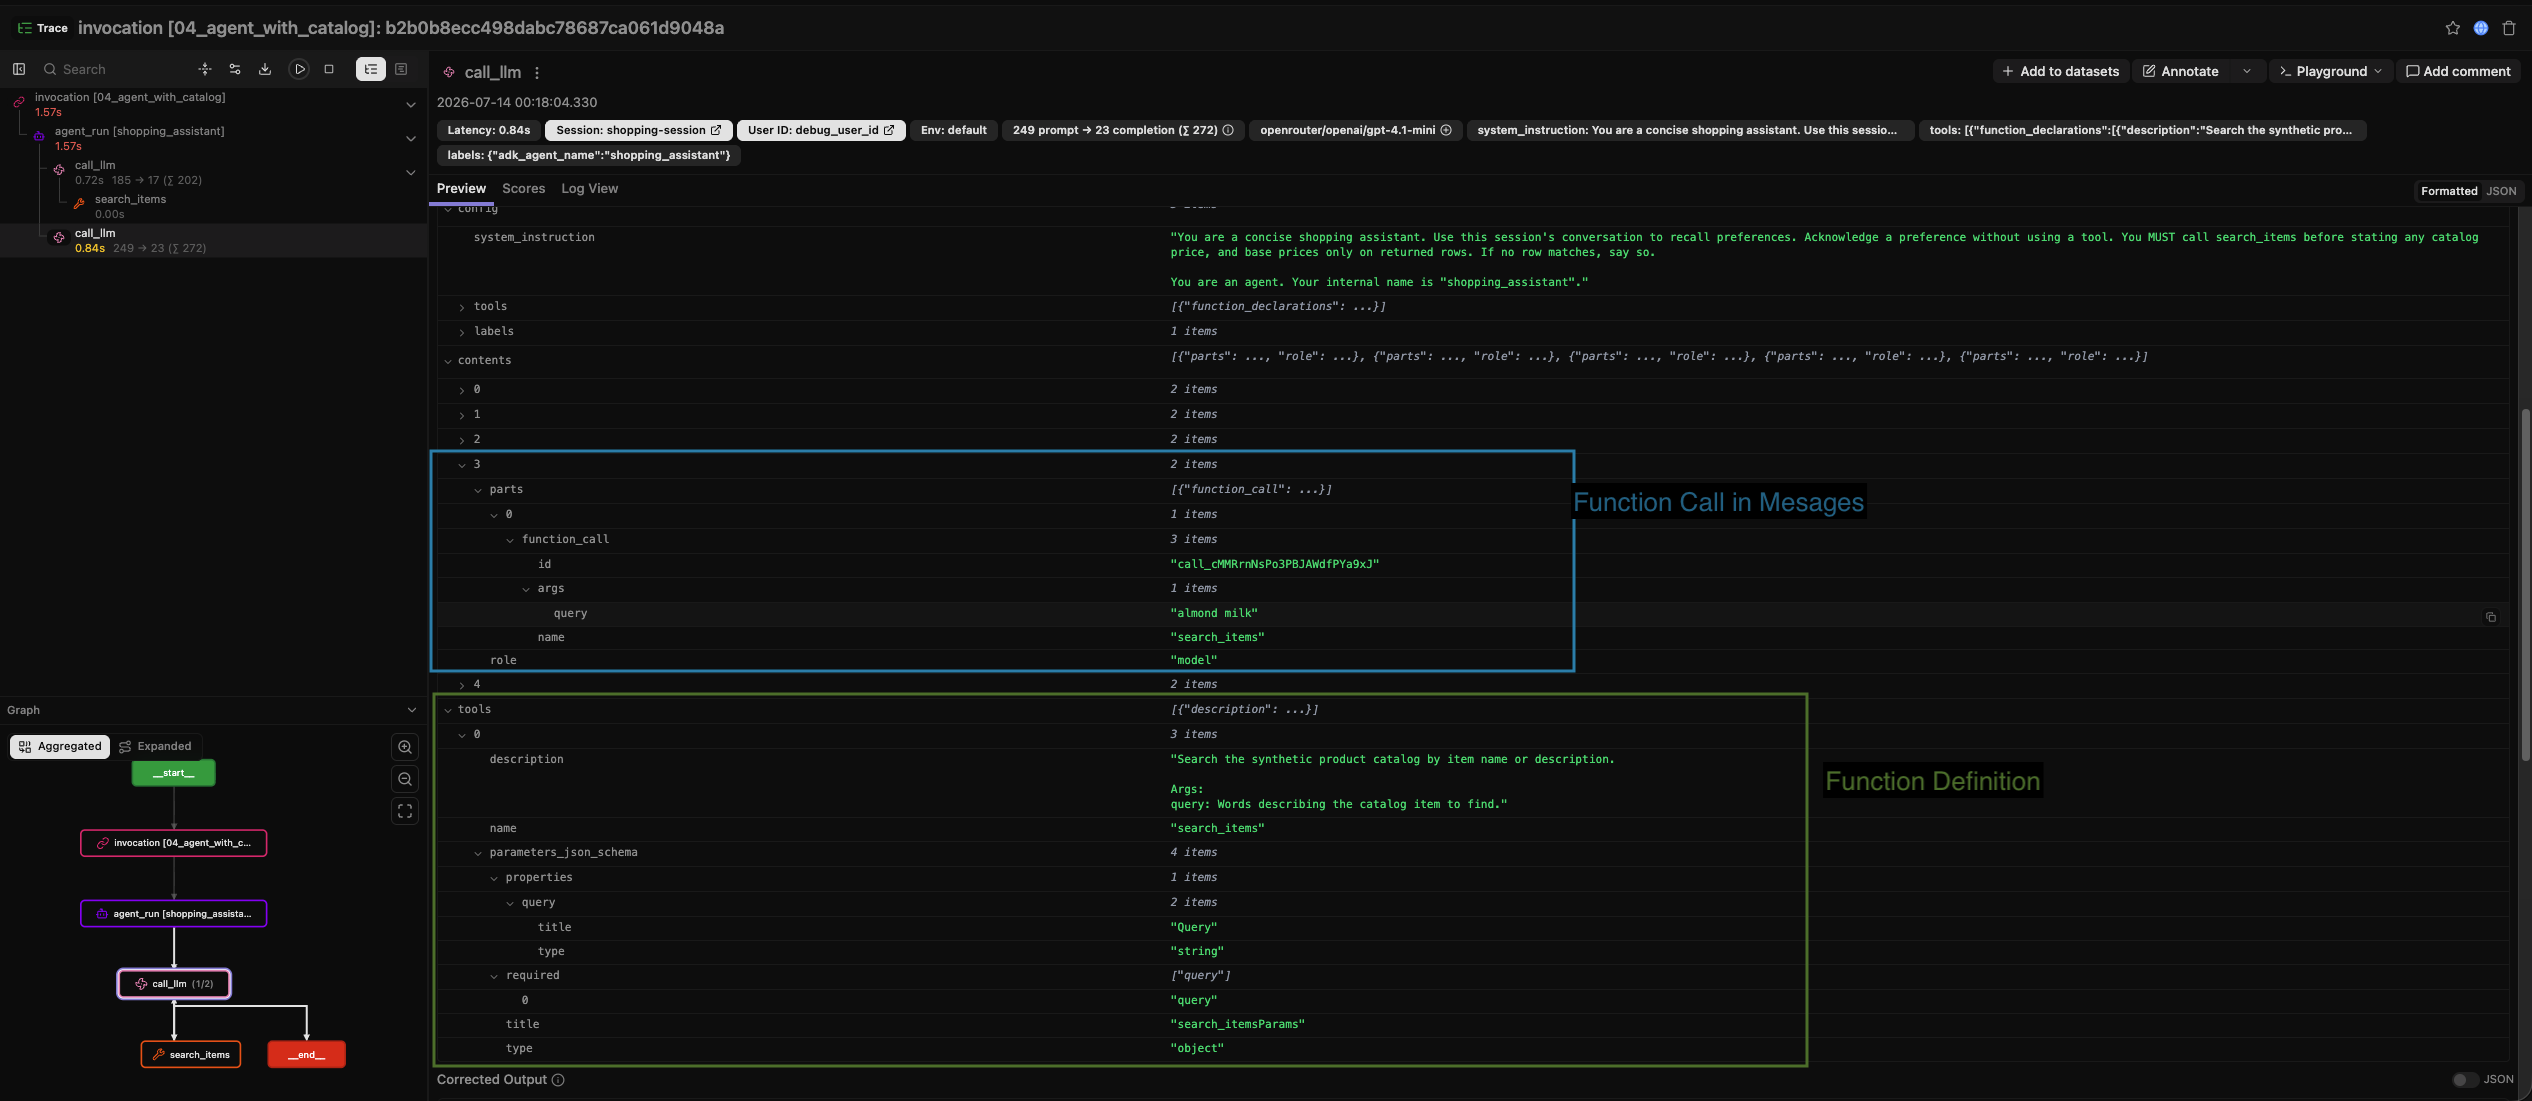

## Next Steps

Try these small exercises:

1. Search for `cereal` or `apples` to confirm the tool is not milk-specific.
2. Ask the price question with a new session ID. What context disappears?
3. Add one synthetic catalog item, then ask the agent about it.
4. Continue to Notebook 2 to compare sub-agents with reusable Agent Skills.

Primary references:

- [Google ADK documentation](https://google.github.io/adk-docs/)
- [OpenRouter API](https://openrouter.ai/docs/api/reference/overview)
- [OpenRouter tool calling](https://openrouter.ai/docs/guides/features/tool-calling)
- [Langfuse + Google ADK](https://langfuse.com/integrations/frameworks/google-adk)
- [Langfuse public trace URLs](https://langfuse.com/docs/observability/features/url)